# Ohio Clinic Dataset - Advanced ML Pipeline

In [1]:
!pip install ydata-profiling optuna-integration

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 359.5/359.5 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.4/93.4 kB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.8/104.8 kB 7.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 686.1/686.1 kB 25.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 23.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.1/380.1 kB 22.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.4/233.4 kB 18.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 6.8 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27080 sha256=7f343df5e91e208828d415515d1be1610182b502afdf7279e8bc9819cd6813a0
  Stored in directory: /root/.cache/pip/wheels/dd/91/29/a79cecb328d01739e64017b6fb9a1ab9d8cb1853098ec5966d
Successfully built htmlmin


## Mount GDrive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Imports

In [2]:
import joblib

import matplotlib
import matplotlib.pyplot as plt

import seaborn as sns

import numpy as np
import pandas as pd
from ydata_profiling import ProfileReport

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report

import optuna
from optuna.integration import OptunaSearchCV
from optuna.distributions import (
    IntDistribution ,
    CategoricalDistribution,
    FloatDistribution,
)

In [3]:
from sklearn import set_config

# Set sklearn to show diagrams for pipelines
set_config(display='diagram')

## Constants

In [5]:
# Set the verbose parameter to 1 to see the progress of the optimization
VERBOSE = 1

In [4]:
# Base folder
BASE_URL = "https://raw.githubusercontent.com/serivan/mldmlab/master/Datasets/"

# Define the train and test data paths
TRAIN_DATA_PATH =  BASE_URL + "mldm_ohio_clinic_train.csv"
TEST_DATA_PATH = BASE_URL + "mldm_ohio_clinic_test.csv"

# Define the random state
RANDOM_STATE = 3993

In [6]:
# Define the optuna search hyperparameters
N_TRIALS = 20
N_JOBS = 8
CROSS_VALIDATION = 3

## Load Data

In [8]:
# Load the train and test data from the CSV files using pandas
train_data=pd.read_csv(TRAIN_DATA_PATH)
test_data=pd.read_csv(TEST_DATA_PATH)

### Features Exploration

In [9]:
# Print the first few rows of the train data to explore the columns and data
train_data.shape

(114949, 14)

In [10]:
test_data.shape

(22105, 14)

In [11]:
train_data.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,5.816289e+11,5760331,F,2016-06-01T14:40:47Z,2016-06-01T00:00:00Z,NaN,DA PENHA,0.0,0.0,0.0,0.0,0.0,0.0,No
1,9.731556e+11,5676727,M,2016-05-09T16:20:41Z,2016-05-11T00:00:00Z,32.0,TABUAZEIRO,0.0,0.0,0.0,0.0,0.0,0.0,No
2,3.958823e+13,5638275,M,2016-04-29T07:52:18Z,2016-05-03T00:00:00Z,58.0,CARATOÍRA,0.0,1.0,0.0,0.0,0.0,NaN,No
3,6.737886e+14,5696894,F,2016-05-13T14:34:40Z,2016-05-16T00:00:00Z,28.0,CONSOLAÇÃO,NaN,0.0,0.0,NaN,0.0,0.0,No
4,7.759954e+12,5691063,M,2016-05-12T11:15:06Z,2016-05-13T00:00:00Z,9.0,SÃO CRISTÓVÃO,0.0,0.0,0.0,0.0,0.0,0.0,No


In [14]:
# Print the length of the train and test data
print(f"train: {len(train_data)}")

train: 114949


In [15]:
# Print the frequency of each value in the target column
train_data.nunique()

PatientId         54081
AppointmentID     88422
Gender                2
ScheduledDay      83768
AppointmentDay       27
Age                 104
Neighbourhood        81
Scholarship           2
Hipertension          2
Diabetes              2
Alcoholism            2
Handcap               5
SMS_received          2
No-show               2
dtype: int64

In [16]:
# Print the types of the columns
train_data.dtypes

PatientId         float64
AppointmentID       int64
Gender             object
ScheduledDay       object
AppointmentDay     object
Age               float64
Neighbourhood      object
Scholarship       float64
Hipertension      float64
Diabetes          float64
Alcoholism        float64
Handcap           float64
SMS_received      float64
No-show            object
dtype: object

### Dataset Profiling (Pandas Profiling)

In [17]:
# Profile the train data using the ydata_profiling library
profile=ProfileReport(train_data, title="Ohio Clinic data report", explorative=True)


In [18]:
# Save the profile report to an HTML file
profile.to_file("profile_report_Ohio.html")

/usr/local/lib/python3.10/dist-packages/ydata_profiling/profile_report.py:363: UserWarning: Try running command: 'pip install --upgrade Pillow' to avoid ValueError
  warnings.warn(


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [19]:
profile.to_notebook_iframe()

### Data Visualisation

In [ ]:
# Show the bar chart of the Hipertension column

<Axes: xlabel='No-show', ylabel='Age'>

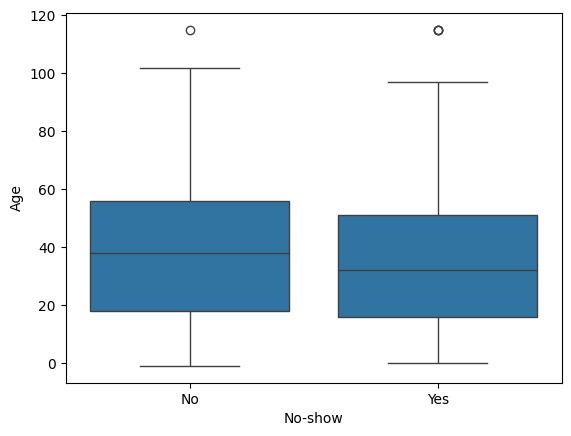

In [30]:
# Plotting Box Plot of Patients’ Age by No-Shows
sns.boxplot(x=train_data["No-show"], y=train_data["Age"])



In [32]:
train_data[train_data["Age"]>105]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
7305,3.196321e+13,5700278,F,2016-05-16T09:17:44Z,2016-05-19T00:00:00Z,115.0,NaN,0.0,0.0,NaN,0.0,1.0,0.0,Yes
22081,3.196321e+13,5700279,F,2016-05-16T09:17:44Z,2016-05-19T00:00:00Z,115.0,ANDORINHAS,0.0,0.0,0.0,0.0,1.0,0.0,Yes
73568,3.196321e+13,5562812,F,2016-04-08T14:29:17Z,2016-05-16T00:00:00Z,115.0,ANDORINHAS,0.0,0.0,0.0,0.0,1.0,0.0,Yes
74091,7.482346e+14,5717451,F,2016-05-19T07:57:56Z,2016-06-03T00:00:00Z,115.0,SÃO JOSÉ,0.0,NaN,0.0,0.0,0.0,1.0,No


In [33]:
train_data["ScheduledDayDT"] = pd.to_datetime(train_data["ScheduledDay"])
train_data["ScheduledDayDT"]

0        2016-06-01 14:40:47+00:00
1        2016-05-09 16:20:41+00:00
2        2016-04-29 07:52:18+00:00
3        2016-05-13 14:34:40+00:00
4        2016-05-12 11:15:06+00:00
                    ...           
114944   2016-04-20 16:21:21+00:00
114945   2016-05-16 12:22:39+00:00
114946   2016-05-09 09:35:28+00:00
114947   2016-06-01 07:23:50+00:00
114948   2016-04-27 07:45:32+00:00
Name: ScheduledDayDT, Length: 114949, dtype: datetime64[ns, UTC]

In [35]:
train_data["ScheduledDayofWeek"] = train_data["ScheduledDayDT"].dt.weekday
train_data["ScheduledDayofWeek"]

0         2
1         0
2         4
3         4
4         3
         ..
114944    2
114945    0
114946    0
114947    2
114948    2
Name: ScheduledDayofWeek, Length: 114949, dtype: int32

In [34]:
train_data["AppointmentDayDT"] = pd.to_datetime(train_data["AppointmentDay"])
train_data["AppointmentDayDT"]

0        2016-06-01 00:00:00+00:00
1        2016-05-11 00:00:00+00:00
2        2016-05-03 00:00:00+00:00
3        2016-05-16 00:00:00+00:00
4        2016-05-13 00:00:00+00:00
                    ...           
114944   2016-05-11 00:00:00+00:00
114945   2016-06-03 00:00:00+00:00
114946   2016-06-08 00:00:00+00:00
114947   2016-06-01 00:00:00+00:00
114948   2016-05-17 00:00:00+00:00
Name: AppointmentDayDT, Length: 114949, dtype: datetime64[ns, UTC]

In [36]:
train_data["AppointmentDayofWeek"] = train_data["AppointmentDayDT"].dt.weekday
train_data["AppointmentDayofWeek"]

0         2
1         2
2         1
3         0
4         4
         ..
114944    2
114945    4
114946    2
114947    2
114948    1
Name: AppointmentDayofWeek, Length: 114949, dtype: int32

In [28]:
train_data["ScheduledDay"].dt.weekday_name


AttributeError: Can only use .dt accessor with datetimelike values

### Data Issues Identification

In [38]:
# Count the number of missing values in each column of the train data
train_data.isnull().sum()

PatientId                   0
AppointmentID               0
Gender                  11462
ScheduledDay                0
AppointmentDay              0
Age                     11528
Neighbourhood           11466
Scholarship             11451
Hipertension            11554
Diabetes                11456
Alcoholism              11512
Handcap                 11472
SMS_received            11612
No-show                     0
ScheduledDayDT              0
AppointmentDayDT            0
ScheduledDayofWeek          0
AppointmentDayofWeek        0
dtype: int64

## Data Preprocessing

### Duplicates removal

In [39]:
# Remove duplicates from the train data
train_data = train_data.drop_duplicates()
test_data = test_data.drop_duplicates()

In [40]:
# Print the new shapes for train and test data
train_data.shape, test_data.shape

((88422, 18), (22105, 14))

### X and y split

In [42]:
columns_to_drop = ["PatientId"] # Columns to drop before X and y creation

In [43]:
# Divide the train and test data into features and target
X_train = train_data.drop(columns=["No-show"])
y_train = train_data["No-show"]

X_test = test_data.drop(columns=["No-show"])
y_test = test_data["No-show"]

### Convert the target column to binary values

In [44]:
# Convert the target column to binary values
y_train = y_train.map({"No": 0, "Yes": 1})
y_test = y_test.map({"No": 0, "Yes": 1})

In [45]:
y_train

0        0
1        0
2        0
3        0
4        0
        ..
88417    1
88418    0
88419    1
88420    0
88421    0
Name: No-show, Length: 88422, dtype: int64

In [46]:
# Count the values for mapping check
y_train.value_counts()

No-show
0    70539
1    17883
Name: count, dtype: int64

## Classification Pipeline Definition

### In-Pipeline Columns Selection and Transformation

In [48]:
# Define the column transformation for the numerical columns considering that
# 1) there are missing values and they have to be imputed
# 2) the age column has a to be always positive
# 3) the columns have to be scaled

# Define the numerical columns to be transformed
numerical_columns = ["Age", "ScheduledDayofWeek", "AppointmentDayofWeek"]

# Create the numerical pipeline with the SimpleImputer and MinMaxScaler
numerical_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="mean")),
        ("abs_transformer", FunctionTransformer(np.abs, validate=True)),
        ("scaler", MinMaxScaler()),
    ]
)


<>:12: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
<>:12: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
<ipython-input-48-b0adbd215894>:12: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
  ("imputer", SimpleImputer(strategy="mean"))


TypeError: 'tuple' object is not callable

In [ ]:
# Define the column transformation for logical columns considering that
# 1) there are missing values and they have to be imputed

# Define the logical columns to be transformed
logical_columns=[
    "Scholarship",
    "Hipertension",
    "Diabetes",
    "Alcoholism",
    "SMS_received",
]

# Create the logical pipeline with the SimpleImputer
logical_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent"))
    ]
)

In [ ]:
# Define the column transformation for the string columns considering that
# 1) there are missing values and they have to be imputed
# 2) the columns have to be encoded using numerical encoding

# Define the categorical columns in the string format to be transformed
categorical_columns = [
    "Gender",
    "Neighbourhood",
]

# Create the string pipeline with the SimpleImputer and OneHotEncoder
categorical_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent"))
        ("one_hot_encoder", OneHotEncoder(handle_unknown="infrequent_if_exist"))
    ]
)

### Preprocessor

In [47]:
# Define the preprocessor with the ColumnTransformer and the defined pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_columns),
        ("log", logical_pipeline, logical_columns),
        ("cat", categorical_pipeline, categorical_columns)
    ]
)

NameError: name 'numerical_pipeline' is not defined

In [ ]:
# Show the preprocessor diagram


In [ ]:
# Show the preprocessor parameters


###  Classification Model

In [ ]:
# Define the classifier model to be used


In [ ]:
# Show the classifier diagram


In [ ]:
# Show the classifier parameters


### Classification Pipeline

In [ ]:
# Define the classification pipeline with the preprocessor and the classifier


In [ ]:
# Show the pipeline diagram


In [ ]:
# Show the pipeline parameters


In [ ]:
# Define the scoring metrics for the classification

### Hyperparameter Tuning (Optuna)

In [ ]:
# Define the parameter search space for the classifier and the preprocessor for the OptunaSearchCV


In [ ]:
# Create the optuna study for the optimization


In [ ]:
# Define the OptunaSearchCV with the pipeline, the parameter search space, and the number of trials


In [ ]:
# Display the OptunaSearchCV diagram


In [ ]:
# Display the OptunaSearchCV parameters


## Run Experiment

###   Pipeline Training

In [ ]:
# Fit the OptunaSearchCV with the train data


In [ ]:
# Show the best parameters found by the OptunaSearchCV


In [ ]:
# Show the best score found by the OptunaSearchCV


In [ ]:
# Show the best estimator found by the OptunaSearchCV


### Pipeline Saving

In [ ]:
# Save the classification pipeline to a file using joblib


### Pipeline Reloading

In [ ]:
# Load the classification pipeline from a file using joblib


### Pipeline Evaluation

In [ ]:
# Evaluate the classification pipeline on the test data


In [ ]:
# Predict the target values using the classification pipeline


In [ ]:
# Print the classification report


# Exercises

1. Find the best scaler between MinMaxScaler, StandardScaler, RobustScaler
1. Use IterativeImputer instead of SimpleImputer
1. Transform the data using PCA in the Pipeline and find the best N components
1. Change the classification model using XGBoost